In [1]:
!pip install numpy pandas scikit-learn matplotlib xlrd seaborn

  Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached xlrd-2.0.2-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolve

In [ ]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Descriptive Statistics:
            SEM 1       SEM 2       SEM 3       SEM 4       SEM 5
count  307.000000  307.000000  307.000000  307.000000  307.000000
mean     7.213713    7.344951    7.432606    7.535603    7.382997
std      1.779933    1.664508    1.521954    1.480903    1.544506
min      1.100000    1.000000    1.440000    1.000000    1.500000
25%      6.450000    6.700000    6.980000    7.100000    6.880000
50%      7.490000    7.650000    7.710000    7.830000    7.700000
75%      8.495000    8.545000    8.440000    8.550000    8.380000
max      9.800000    9.880000    9.730000    9.880000    9.640000


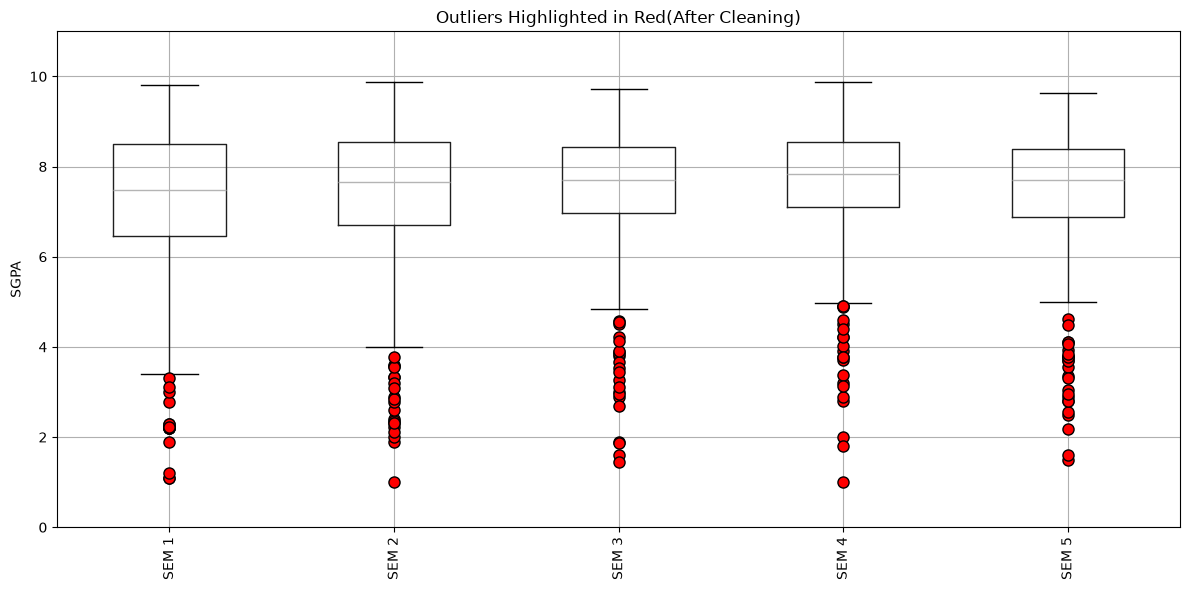

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


data = pd.read_excel("./cgpaPRED.xls", engine='xlrd')
data = data.dropna()

numeric_data = data.select_dtypes(include=[np.number])


numeric_data = numeric_data[(numeric_data >= 1.0).all(axis=1)]

print("Descriptive Statistics:")
print(numeric_data.describe())

red_circle = dict(markerfacecolor='r', marker='o', markersize=8)

numeric_data.boxplot(
    figsize=(12, 6),
    flierprops=red_circle,
    rot=90
)
plt.ylim(0, 11)
plt.title(f"Outliers Highlighted in Red(After Cleaning)")
plt.ylabel("SGPA")
plt.tight_layout()
plt.show()


In [ ]:
# train and test split of the data set
train, test = train_test_split(numeric_data)

In [23]:
model = LinearRegression()

model.fit(X=train[['SEM 4']], y=train['SEM 5'])

y_predict = model.predict(test[['SEM 4']])
print()

y_true = test['SEM 5']

mse = mean_squared_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)
mea = mean_absolute_error(y_test, y_predict)

print("Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_mlr:.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse_mlr):.4f}")
print(f"R-squared (R2) Score: {r2_mlr:.4f}")
print(f"Mean Absolute Error (MEA) Score: {mea:.4f}")
print(y_predict)


Model Evaluation:
Mean Squared Error (MSE): 0.0000
Root Mean Squared Error (RMSE): 0.0028
R-squared (R2) Score: 1.0000
Mean Absolute Error (MEA) Score: 0.3468
[9.00359681 5.06862871 8.32010359 7.73425226 8.16387657 7.44132659
 8.71067114 7.73425226 6.99217391 3.08649838 8.33963197 7.53896848
 8.06623468 8.38845291 8.2224617  8.9254833  5.43966788 5.87905638
 8.05647049 8.51538736 7.49014754 6.78712594 8.27128264 6.89453202
 8.9254833  8.85713397 6.67971986 7.50967592 8.15411238 8.16387657
 8.72043533 4.41442806 7.24604282 8.05647049 7.12887255 8.14434819
 7.34368471 9.03288937 8.70090695 7.07028742 8.35916034 8.42750967
 7.96859279 8.03694211 6.84571107 7.72448807 9.33557923 8.71067114
 9.55039138 2.84239365 5.34202599 9.13053126 7.73425226 7.77330901
 9.24770153 6.19151042 8.73996371 7.17769349 7.81236577 8.12481981
 8.08576306 7.05075904 8.42750967 8.50562318 7.81236577 8.60326506
 6.5625496  8.14434819 8.78878465 7.73425226 4.79523142 8.49585899
 9.55039138 6.99217391 7.73425226 4.

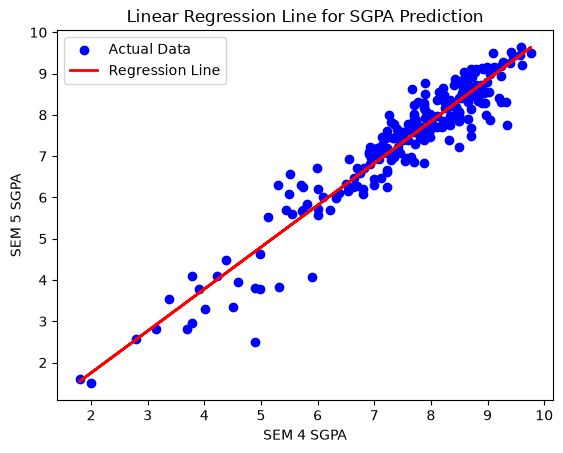

In [8]:
# Create the scatter plot of the actual training data
plt.scatter(train[['SEM 4']], train['SEM 5'], color='blue', label='Actual Data')

X_line = train[['SEM 4']]
y_line = model.predict(X_line)

plt.plot(X_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel('SEM 4 SGPA')
plt.ylabel('SEM 5 SGPA')
plt.title('Linear Regression Line for SGPA Prediction')
plt.legend()
plt.show()


d:\All codes and Projects\college\AML-Lab-3\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


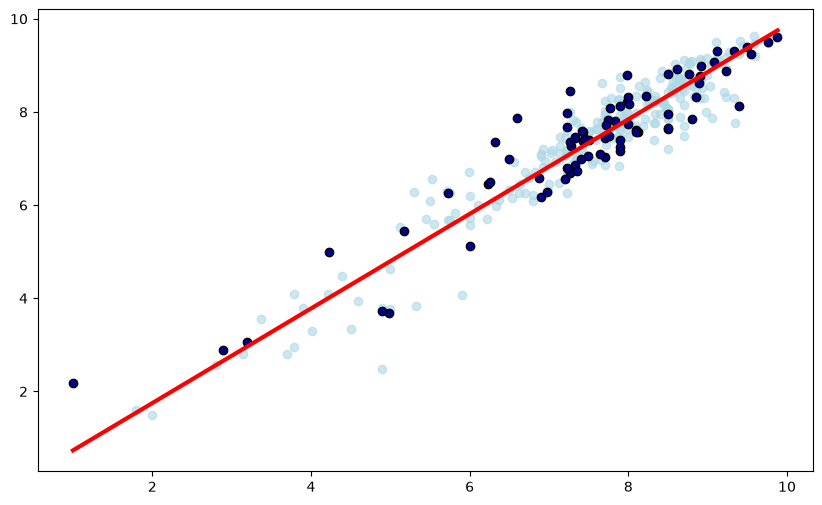

In [9]:
plt.figure(figsize=(10, 6))

plt.scatter(train[['SEM 4']], train['SEM 5'], color='lightblue', alpha=0.6, label='Train Data')
plt.scatter(test[['SEM 4']], test['SEM 5'], color='darkblue', edgecolors='black', label='Test Data')

x_bounds = np.array([[numeric_data['SEM 4'].min()], [numeric_data['SEM 4'].max()]])
y_bounds = model.predict(x_bounds)

plt.plot(x_bounds, y_bounds, color='red', linewidth=3, label='The Trained Model Line')


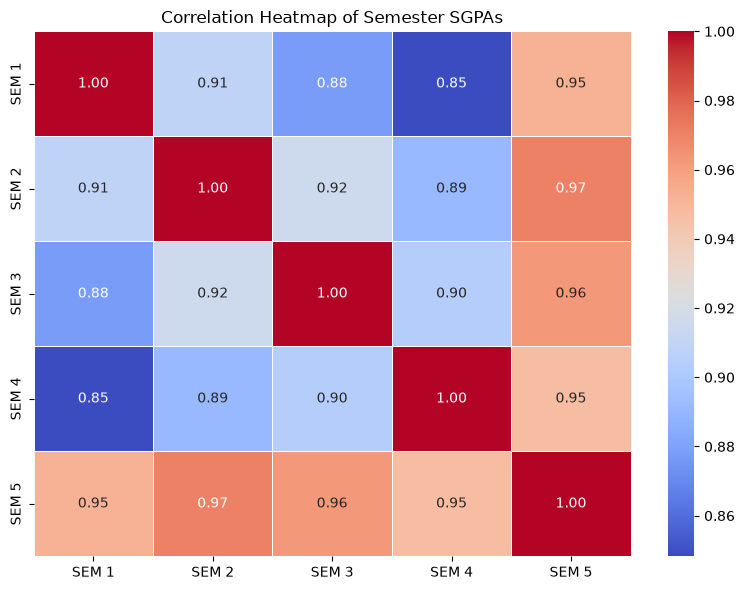

In [10]:
import seaborn as sns
correlation_matrix = numeric_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap of Semester SGPAs")
plt.tight_layout()
plt.show()


## Multiple Linear Regression

Now, let's predict `SEM 5` SGPA using all previous semesters' GPAs (`SEM 1`, `SEM 2`, `SEM 3`, and `SEM 4`) as multiple input features.

In [20]:
# 1. Define multiple features (X) and target (y)
features = ['SEM 1', 'SEM 2', 'SEM 3', 'SEM 4']
X_train = train[features]
y_train = train['SEM 5']

X_test = test[features]
y_test = test['SEM 5']

# 2. Train Multiple Linear Regression model
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

# 3. Display the Intercept and Coefficients
print("Multiple Linear Regression Model Details:")
print(f"Intercept: {mlr_model.intercept_:.4f}")
print("Coefficients:")
for col, coef in zip(features, mlr_model.coef_):
    print(f"  {col}: {coef:.4f}")

Multiple Linear Regression Model Details:
Intercept: 0.0002
Coefficients:
  SEM 1: 0.2496
  SEM 2: 0.2502
  SEM 3: 0.2499
  SEM 4: 0.2504


In [ ]:

# 1. Predict on the test set
y_pred_mlr = mlr_model.predict(X_test)

# 2. Calculate and print performance metrics
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)
mea = mean_absolute_error(y_test, y_pred_mlr)

print("Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_mlr:.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse_mlr):.4f}")
print(f"R-squared (R2) Score: {r2_mlr:.4f}")
print(f"Mean Absolute Error (MEA) Score: {mea:.4f}")

Model Evaluation:
Mean Squared Error (MSE): 0.0000
Root Mean Squared Error (RMSE): 0.0028
R-squared (R2) Score: 1.0000
Mean Absolute Error (MEA) Score: 0.0025


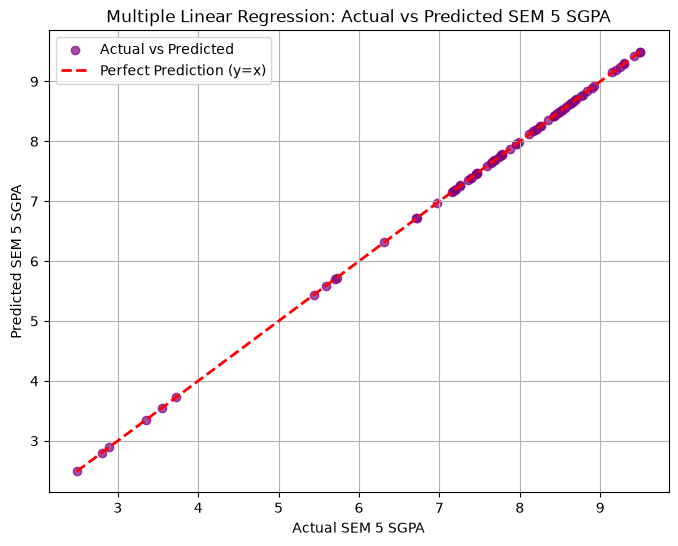

In [22]:
# Plot Actual vs Predicted values for Multiple Linear Regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_mlr, color='purple', alpha=0.7, label='Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')
plt.xlabel('Actual SEM 5 SGPA')
plt.ylabel('Predicted SEM 5 SGPA')
plt.title('Multiple Linear Regression: Actual vs Predicted SEM 5 SGPA')
plt.legend()
plt.grid(True)
plt.show()